# State Space Models

In [ ]:
import sys
import os
main_dir = os.path.dirname(os.getcwd())
sys.path.append(main_dir)

import argparse
import os
import time

import numpy as np

from RemoteSensing.changedetection.configs.config import get_config

import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from RemoteSensing.changedetection.datasets.make_data_loader import SemanticChangeDetectionDatset, make_data_loader
from RemoteSensing.changedetection.utils_func.metrics import Evaluator
from RemoteSensing.changedetection.models.STMambaSCD import STMambaSCD
import RemoteSensing.changedetection.utils_func.lovasz_loss as L
from torch.optim.lr_scheduler import StepLR

from RemoteSensing.changedetection.utils_func.mcd_utils import accuracy, SCDD_eval_all, AverageMeter
import matplotlib.pyplot as plt

/home/e19063/ChangeDetection-Buddhi/RemoteSensing/classification/models/vmamba.py:252: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd
/home/e19063/ChangeDetection-Buddhi/RemoteSensing/classification/models/vmamba.py:260: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_bwd
/home/e19063/ChangeDetection-Buddhi/RemoteSensing/classification/models/vmamba.py:275: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd
/home/e19063/ChangeDetection-Buddhi/RemoteSensing/classification/models/vmamba.py:283: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @torch.

In [17]:
import random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [18]:
torch.cuda.set_device(0)

In [19]:
MODEL_PATH = os.path.join(
    main_dir, "RemoteSensing/saved_models/convo_attention/19500_model.pth"
)

In [20]:
configs_path = os.path.join(main_dir, 'MambaCD/changedetection/configs/vssm1/vssm_base_224.yaml')
VSSM_MODEL_PATH = os.path.join(
    main_dir, 'MambaCD/pretrained/vssm_base_0229_ckpt_epoch_237.pth'
)

SECOND_DATASET_PATH = os.path.join(main_dir, 'Datasets', 'SECOND')
SECOND_TRAIN_DATASET_PATH = os.path.join(SECOND_DATASET_PATH, 'train')
SECOND_TEST_DATASET_PATH = os.path.join(SECOND_DATASET_PATH, 'test')
SECOND_TRAIN_DATA_LIST_PATH = os.path.join(SECOND_DATASET_PATH, 'train.txt')
SECOND_TEST_DATA_LIST_PATH = os.path.join(SECOND_DATASET_PATH, 'test.txt')

train_data_list = []
with open(SECOND_TRAIN_DATA_LIST_PATH, 'r') as f:
    for line in f:
        train_data_list.append(line.strip())

test_data_list = []
with open(SECOND_TEST_DATA_LIST_PATH, 'r') as f:
    for line in f:
        test_data_list.append(line.strip())

class ARGS:
    def __init__(self):
        self.cfg = configs_path
        self.opts = None
        self.pretrained_weight_path = VSSM_MODEL_PATH
        self.dataset = 'SECOND'
        self.type = 'train'
        self.train_dataset_path = SECOND_TRAIN_DATASET_PATH
        self.train_data_list_path = SECOND_TRAIN_DATA_LIST_PATH
        self.test_dataset_path = SECOND_TEST_DATASET_PATH
        self.test_data_list_path = SECOND_TEST_DATA_LIST_PATH
        self.shuffle = False
        self.batch_size = 1
        self.crop_size = 256
        self.train_data_name_list = train_data_list
        self.test_data_name_list = test_data_list
        self.start_iter = 0
        self.cuda = False
        self.max_iters = 400000
        self.model_type = 'MambaSCD'
        self.model_param_path = None 
        self.resume = MODEL_PATH
        self.learning_rate = 1e-4
        self.momentum = 0.9
        self.weight_decay = 5e-4

args = ARGS()

In [21]:
args = args
config = get_config(args)

train_data_loader = make_data_loader(args)

deep_model = STMambaSCD(
    output_cd = 2, 
    output_clf = 7,
    pretrained=args.pretrained_weight_path,
    patch_size=config.MODEL.VSSM.PATCH_SIZE, 
    in_chans=config.MODEL.VSSM.IN_CHANS, 
    num_classes=config.MODEL.NUM_CLASSES, 
    depths=config.MODEL.VSSM.DEPTHS, 
    dims=config.MODEL.VSSM.EMBED_DIM, 
    # ===================
    ssm_d_state=config.MODEL.VSSM.SSM_D_STATE,
    ssm_ratio=config.MODEL.VSSM.SSM_RATIO,
    ssm_rank_ratio=config.MODEL.VSSM.SSM_RANK_RATIO,
    ssm_dt_rank=("auto" if config.MODEL.VSSM.SSM_DT_RANK == "auto" else int(config.MODEL.VSSM.SSM_DT_RANK)),
    ssm_act_layer=config.MODEL.VSSM.SSM_ACT_LAYER,
    ssm_conv=config.MODEL.VSSM.SSM_CONV,
    ssm_conv_bias=config.MODEL.VSSM.SSM_CONV_BIAS,
    ssm_drop_rate=config.MODEL.VSSM.SSM_DROP_RATE,
    ssm_init=config.MODEL.VSSM.SSM_INIT,
    forward_type=config.MODEL.VSSM.SSM_FORWARDTYPE,
    # ===================
    mlp_ratio=config.MODEL.VSSM.MLP_RATIO,
    mlp_act_layer=config.MODEL.VSSM.MLP_ACT_LAYER,
    mlp_drop_rate=config.MODEL.VSSM.MLP_DROP_RATE,
    # ===================
    drop_path_rate=config.MODEL.DROP_PATH_RATE,
    patch_norm=config.MODEL.VSSM.PATCH_NORM,
    norm_layer=config.MODEL.VSSM.NORM_LAYER,
    downsample_version=config.MODEL.VSSM.DOWNSAMPLE,
    patchembed_version=config.MODEL.VSSM.PATCHEMBED,
    gmlp=config.MODEL.VSSM.GMLP,
    use_checkpoint=config.TRAIN.USE_CHECKPOINT,
    ) 

deep_model.load_state_dict(torch.load(MODEL_PATH))
deep_model.cuda()
deep_model.eval()

=> merge config from /home/e19063/ChangeDetection-Buddhi/MambaCD/changedetection/configs/vssm1/vssm_base_224.yaml


/home/e19063/ChangeDetection-Buddhi/RemoteSensing/changedetection/models/Mamba_backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _ckpt = torch.load(open(ckpt, "r

Successfully load ckpt /home/e19063/ChangeDetection-Buddhi/MambaCD/pretrained/vssm_base_0229_ckpt_epoch_237.pth
_IncompatibleKeys(missing_keys=['outnorm0.weight', 'outnorm0.bias', 'outnorm1.weight', 'outnorm1.bias', 'outnorm2.weight', 'outnorm2.bias', 'outnorm3.weight', 'outnorm3.bias'], unexpected_keys=['classifier.norm.weight', 'classifier.norm.bias', 'classifier.head.weight', 'classifier.head.bias'])
False


/tmp/ipykernel_1308728/1844136451.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  deep_model.load_state_dict(torch.load(MODEL_PATH))


STMambaSCD(
  (encoder): Backbone_VSSM(
    (patch_embed): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): Permute()
      (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (3): Permute()
      (4): GELU(approximate='none')
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (6): Permute()
      (7): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (layers): ModuleList(
      (0): Sequential(
        (blocks): Sequential(
          (0): VSSBlock(
            (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (op): SS2D(
              (out_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
              (in_proj): Linear(in_features=128, out_features=256, bias=False)
              (act): SiLU()
              (conv2d): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=False)
              (out_proj): Linear(in_

# Image Lib

In [22]:
ori_label_value_dict = {
    'background': (0, 0, 0),
    'low_vegetation': (0, 128, 0),
    'nvg_surface': (128, 128, 128),
    'tree': (0, 255, 0),
    'water': (0, 0, 255),
    'Building': (128, 0, 0),
    'Playground': (255, 0, 0)
}

target_label_value_dict = {
    'background': 0,
    'low_vegetation': 1,
    'nvg_surface': 2,
    'tree': 3,
    'water': 4,
    'Building': 5,
    'Playground': 6
}

def map_labels_to_colors(labels, ori_label_value_dict, target_label_value_dict):
    # Reverse the target_label_value_dict to get a mapping from target labels to original labels
    target_to_ori = {v: k for k, v in target_label_value_dict.items()}
    
    # Initialize an empty 3D array for the color-mapped labels
    H, W = labels.shape
    color_mapped_labels = np.zeros((H, W, 3), dtype=np.uint8)
    
    for target_label, ori_label in target_to_ori.items():
        # Find where the label matches the current target label
        mask = labels == target_label
        
        # Map these locations to the corresponding color value
        color_mapped_labels[mask] = ori_label_value_dict[ori_label]
    
    return color_mapped_labels

In [23]:
def get_first_batch():
    return next(iter(train_data_loader))

data = get_first_batch()

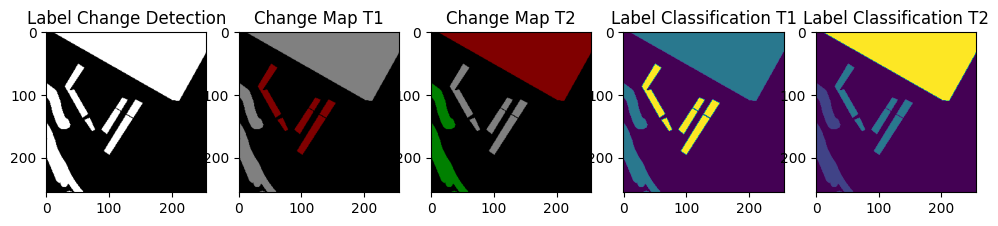

In [24]:
pre_change_imgs, post_change_imgs, label_cd, label_clf_t1, label_clf_t2, _ = data

pre_change_imgs = pre_change_imgs.cuda()
post_change_imgs = post_change_imgs.cuda()
label_cd = label_cd.cuda().long()
label_clf_t1 = label_clf_t1.cuda().long()
label_clf_t2 = label_clf_t2.cuda().long()

change_map_T1 = map_labels_to_colors(np.squeeze(label_clf_t1.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)
change_map_T2 = map_labels_to_colors(np.squeeze(label_clf_t2.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)

fig1, axes = plt.subplots(1, 5, figsize=(12, 4))
axes[0].imshow(label_cd[0].cpu().numpy(), cmap='gray')
axes[0].set_title('Label Change Detection')
axes[1].imshow(change_map_T1)
axes[1].set_title('Change Map T1')
axes[2].imshow(change_map_T2)
axes[2].set_title('Change Map T2')
axes[3].imshow(label_clf_t1[0].cpu().numpy())
axes[3].set_title('Label Classification T1')
axes[4].imshow(label_clf_t2[0].cpu().numpy())
axes[4].set_title('Label Classification T2')
plt.show()

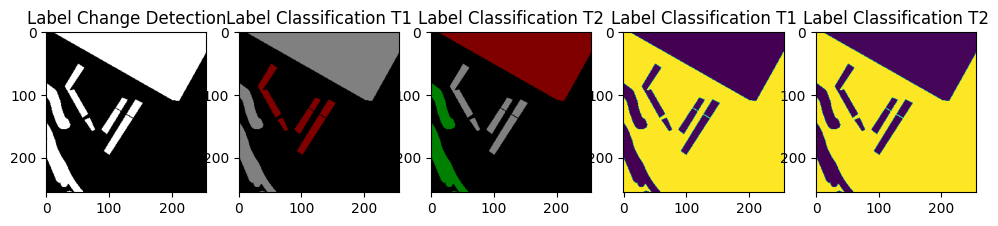

In [25]:
label_clf_t1[label_clf_t1 == 0] = 255
label_clf_t2[label_clf_t2 == 0] = 255

change_map_T1 = map_labels_to_colors(np.squeeze(label_clf_t1.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)
change_map_T2 = map_labels_to_colors(np.squeeze(label_clf_t2.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)

fig1, axes = plt.subplots(1, 5, figsize=(12, 4))
axes[0].imshow(label_cd[0].cpu().numpy(), cmap='gray')
axes[0].set_title('Label Change Detection')
axes[1].imshow(change_map_T1)
axes[1].set_title('Label Classification T1')
axes[2].imshow(change_map_T2)
axes[2].set_title('Label Classification T2')
axes[3].imshow(label_clf_t1[0].cpu().numpy())
axes[3].set_title('Label Classification T1')
axes[4].imshow(label_clf_t2[0].cpu().numpy())
axes[4].set_title('Label Classification T2')
plt.show()

In [26]:
output_1, output_semantic_t1_, output_semantic_t2_ = deep_model(pre_change_imgs, post_change_imgs)

In [27]:
output_semantic_t1 = output_semantic_t1_.clone()
output_semantic_t2 = output_semantic_t2_.clone()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3815395..1.9776906].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9481792..2.64].


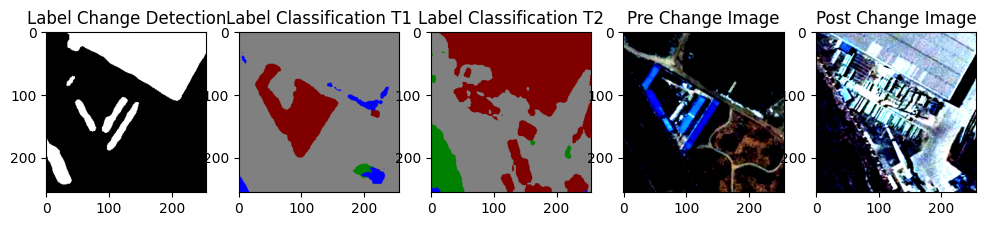

In [28]:
label_out_cd = output_1.clone()
label_out_cd = torch.argmax(label_out_cd, dim=1)

label_out_clf_t1 = output_semantic_t1.clone()
label_out_clf_t1 = torch.argmax(label_out_clf_t1, dim=1)

label_out_clf_t2 = output_semantic_t2.clone()
label_out_clf_t2 = torch.argmax(label_out_clf_t2, dim=1)


label_out_clf_t1 = map_labels_to_colors(np.squeeze(label_out_clf_t1.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)
label_out_clf_t2 = map_labels_to_colors(np.squeeze(label_out_clf_t2.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)

fig1, axes = plt.subplots(1, 5, figsize=(12, 4))
axes[0].imshow(label_out_cd[0].cpu().numpy(), cmap='gray')
axes[0].set_title('Label Change Detection')
axes[1].imshow(label_out_clf_t1)
axes[1].set_title('Label Classification T1')
axes[2].imshow(label_out_clf_t2)
axes[2].set_title('Label Classification T2')
axes[3].imshow(pre_change_imgs[0].cpu().numpy().transpose(1, 2, 0))
axes[3].set_title('Pre Change Image')
axes[4].imshow(post_change_imgs[0].cpu().numpy().transpose(1, 2, 0))
axes[4].set_title('Post Change Image')
plt.show()

# Evaluation

In [29]:
dataset = SemanticChangeDetectionDatset(args.test_dataset_path, args.test_data_name_list, 256, None, 'test')
val_data_loader = DataLoader(dataset, batch_size=8, num_workers=4, drop_last=False)
torch.cuda.empty_cache()
acc_meter = AverageMeter()

preds_all = []
labels_all = []
with torch.no_grad():
    for itera, data in enumerate(val_data_loader):
        pre_change_imgs, post_change_imgs, labels_cd, labels_clf_t1, labels_clf_t2, _ = data

        pre_change_imgs = pre_change_imgs.cuda()
        post_change_imgs = post_change_imgs.cuda()
        labels_cd = labels_cd.cuda().long()
        labels_clf_t1 = labels_clf_t1.cuda().long()
        labels_clf_t2 = labels_clf_t2.cuda().long()


        # input_data = torch.cat([pre_change_imgs, post_change_imgs], dim=1)
        output_1, output_semantic_t1, output_semantic_t2 = deep_model(pre_change_imgs, post_change_imgs)

        labels_cd = labels_cd.cpu().numpy()
        labels_A = labels_clf_t1.cpu().numpy()
        labels_B = labels_clf_t2.cpu().numpy()

        change_mask = torch.argmax(output_1, axis=1).cpu().numpy()

        preds_A = torch.argmax(output_semantic_t1, dim=1).cpu().numpy()
        preds_B = torch.argmax(output_semantic_t2, dim=1).cpu().numpy()

        preds_A[change_mask == 0] = 0
        preds_B[change_mask == 0] = 0

        if itera % 100 == 0:
            print(f'iter is {itera}')

        for (pred_A, pred_B, label_A, label_B) in zip(preds_A, preds_B, labels_A, labels_B):
            acc_A, valid_sum_A = accuracy(pred_A, label_A)
            acc_B, valid_sum_B = accuracy(pred_B, label_B)
            preds_all.append(pred_A)
            preds_all.append(pred_B)
            labels_all.append(label_A)
            labels_all.append(label_B)
            acc = (acc_A + acc_B) * 0.5
            acc_meter.update(acc)

kappa_n0, Fscd, IoU_mean, Sek = SCDD_eval_all(preds_all, labels_all, 37)
print(f'Kappa coefficient rate is {kappa_n0}, F1 is {Fscd}, OA is {acc_meter.avg}, '
        f'mIoU is {IoU_mean}, SeK is {Sek}')

iter is 0
iter is 100
Kappa coefficient rate is 0.37022418781850225, F1 is 0.6483760331227267, OA is 0.8845227872821646, mIoU is 0.736655805832233, SeK is 0.24506544215224718


In [30]:
dataset = SemanticChangeDetectionDatset(args.test_dataset_path, args.test_data_name_list, 256, None, 'test')
val_data_loader = DataLoader(dataset, batch_size=4, num_workers=4, drop_last=False)
torch.cuda.empty_cache()
acc_meter = AverageMeter()

preds_all = []
labels_all = []
with torch.no_grad():
    for itera, data in enumerate(val_data_loader):
        pre_change_imgs, post_change_imgs, labels_cd, labels_clf_t1, labels_clf_t2, _ = data

        pre_change_imgs = pre_change_imgs.cuda()
        post_change_imgs = post_change_imgs.cuda()
        labels_cd = labels_cd.cuda().long()
        labels_clf_t1 = labels_clf_t1.cuda().long()
        labels_clf_t2 = labels_clf_t2.cuda().long()


        # input_data = torch.cat([pre_change_imgs, post_change_imgs], dim=1)
        output_1, output_semantic_t1, output_semantic_t2 = deep_model(pre_change_imgs, post_change_imgs)

        labels_cd = labels_cd.cpu().numpy()
        labels_A = labels_clf_t1.cpu().numpy()
        labels_B = labels_clf_t2.cpu().numpy()

        change_mask = torch.argmax(output_1, axis=1).cpu().numpy()

        preds_A = torch.argmax(output_semantic_t1, dim=1).cpu().numpy()
        preds_B = torch.argmax(output_semantic_t2, dim=1).cpu().numpy()
        

        preds_scd = (preds_A - 1) * 6 + preds_B
        preds_scd[change_mask == 0] = 0

        labels_scd = (labels_A - 1) * 6 + labels_B
        labels_scd[labels_cd == 0] = 0

        for (pred_scd, label_scd) in zip(preds_scd, labels_scd):
            acc_A, valid_sum_A = accuracy(pred_scd, label_scd)
            preds_all.append(pred_scd)
            labels_all.append(label_scd)
            acc = acc_A
            acc_meter.update(acc)

kappa_n0, Fscd, IoU_mean, Sek = SCDD_eval_all(preds_all, labels_all, 37)
print(f'Kappa coefficient rate is {kappa_n0}, F1 is {Fscd}, OA is {acc_meter.avg}, '
        f'mIoU is {IoU_mean}, SeK is {Sek}')

Kappa coefficient rate is 0.35759113505221124, F1 is 0.5677830947147504, OA is 0.8693051827505559, mIoU is 0.7366557705500876, SeK is 0.23670293553633684
